Titanic Dataset - Detailed Exploratory Data Analysis(EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

Load Dataset

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Basic Overview

In [3]:
print("shape:", df.shape)
print("-"*50)
print("columns:", df.columns.tolist())
print("-"*50)
print("Data types:", df.info())
print("-"*50)
print("Summary", df.describe(include="all"))

shape: (891, 15)
--------------------------------------------------
columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  8

Missing values Analysis

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = df.isnull().mean().sort_values(ascending=False)*100
pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


Duplicate Values Analysis

In [5]:
duplicate = df.duplicated()
duplicate_num = duplicate.sum()
print("Total number of duplicate:", duplicate_num)
print("-"*50)
print("Duplicated:", df[duplicate])

Total number of duplicate: 107
--------------------------------------------------
Duplicated:      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
47          1       3  female   NaN      0      0   7.7500        Q   Third   
76          0       3    male   NaN      0      0   7.8958        S   Third   
77          0       3    male   NaN      0      0   8.0500        S   Third   
87          0       3    male   NaN      0      0   8.0500        S   Third   
95          0       3    male   NaN      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
870         0       3    male  26.0      0      0   7.8958        S   Third   
877         0       3    male  19.0      0      0   7.8958        S   Third   
878         0       3    male   NaN      0      0   7.8958        S   Third   
884         0       3    male  25.0      0      0   7.0500        S   Third   
886         0       2    male  27.0  

Target Variable Analyis (Survival)

In [6]:
df['survived'].value_counts()

,count
survived,
0,549
1,342


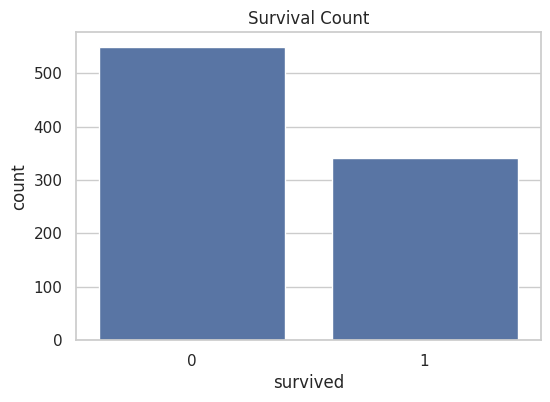

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='survived')
plt.title("Survival Count")
plt.show()

Univariate Analysis - Numeric Features

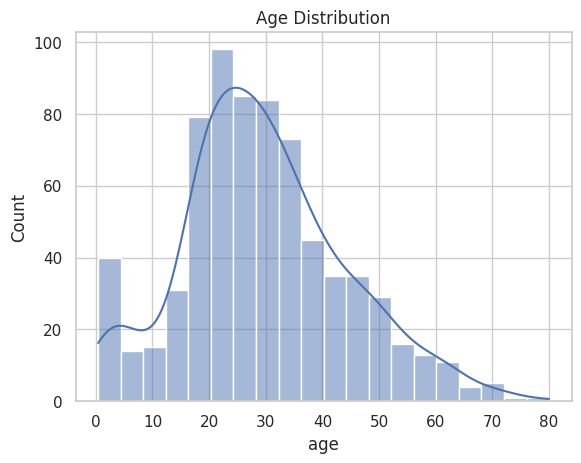

In [8]:
sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

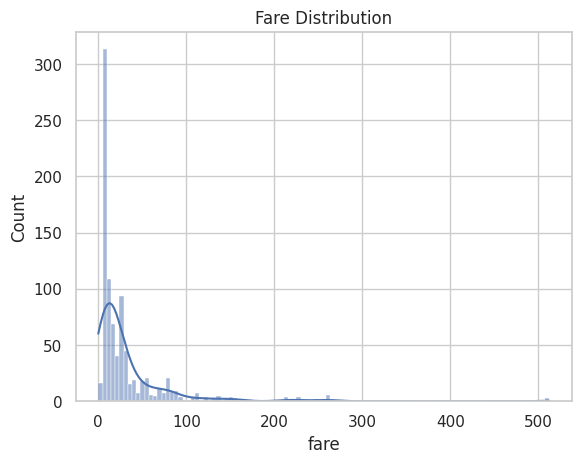

In [9]:
sns.histplot(df['fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

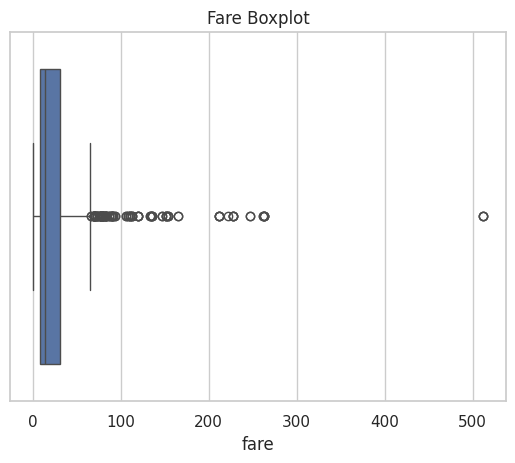

In [10]:
sns.boxplot(x=df['fare'])
plt.title("Fare Boxplot")
plt.show()

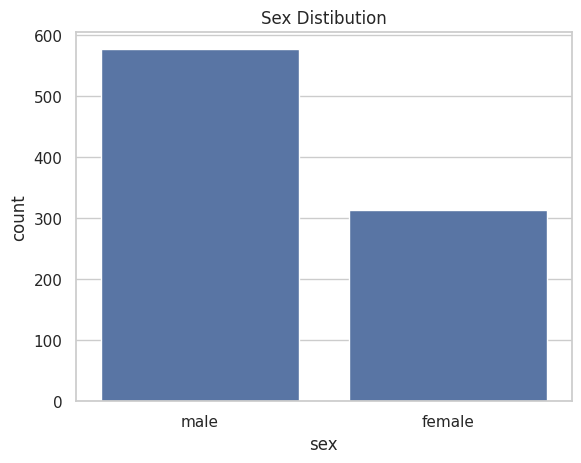

In [11]:
sns.countplot(data=df, x='sex')
plt.title("Sex Distibution")
plt.show()

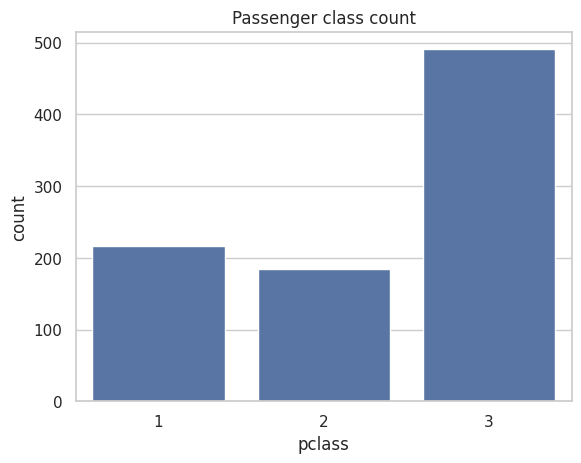

In [12]:
sns.countplot(data=df, x='pclass')
plt.title("Passenger class count")
plt.show()

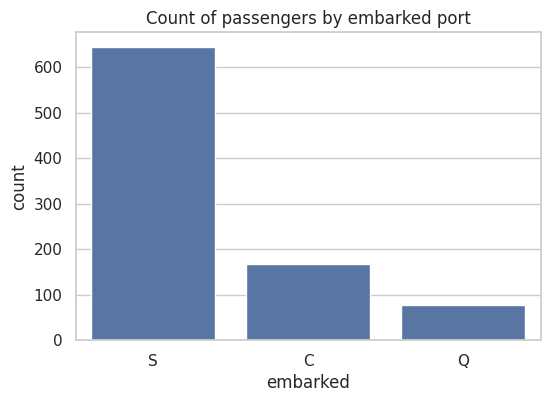

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='embarked')
plt.title("Count of passengers by embarked port")
plt.show()

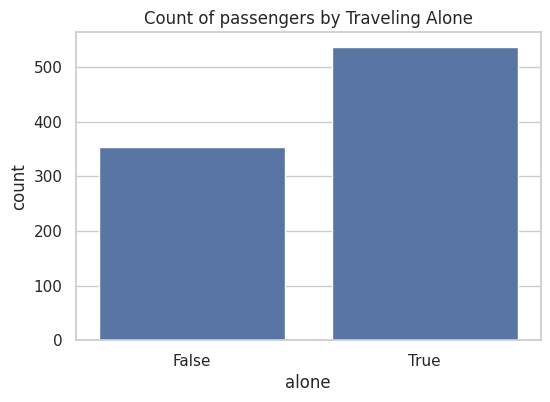

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='alone')
plt.title("Count of passengers by Traveling Alone")
plt.show()

Bivariate Analysis with survial

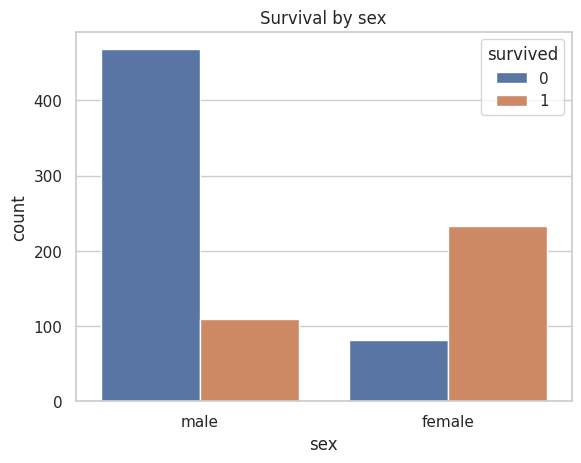

In [15]:
sns.countplot(data=df, x='sex', hue='survived')
plt.title("Survival by sex")
plt.show()

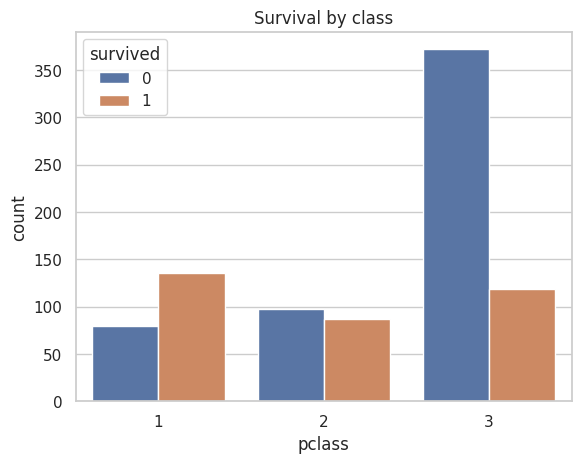

In [16]:
sns.countplot(data=df, x='pclass', hue='survived')
plt.title("Survival by class")
plt.show()

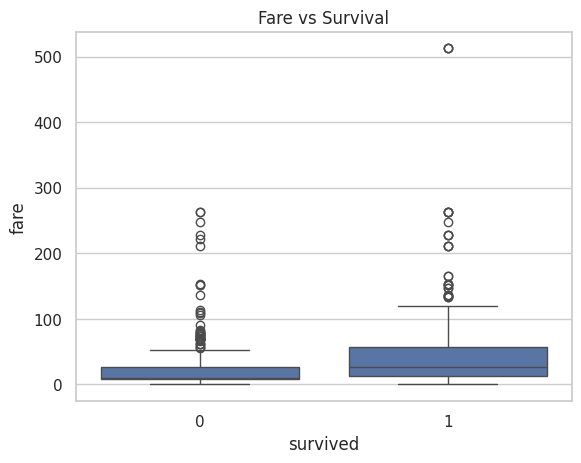

In [17]:
sns.boxplot(data=df, x='survived', y='fare')
plt.title("Fare vs Survival")
plt.show()

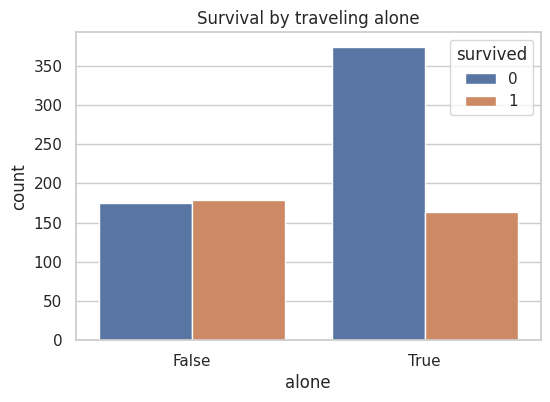


Survival rate by alone:
alone
False    0.505650
True     0.303538
Name: survived, dtype: float64


In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='alone', hue='survived')
plt.title("Survival by traveling alone")
plt.show()

print("\nSurvival rate by alone:")
print(df.groupby("alone")['survived'].mean().sort_values(ascending=False))

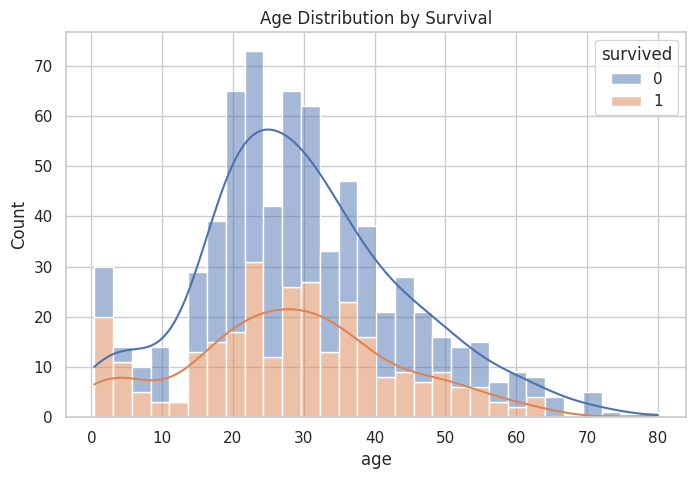

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue='survived', bins=30, kde=True, multiple="stack")
plt.title("Age Distribution by Survival")
plt.show()

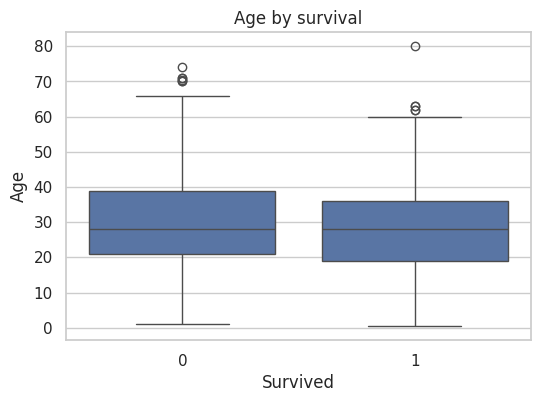

In [20]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='survived', y='age')
plt.title("Age by survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

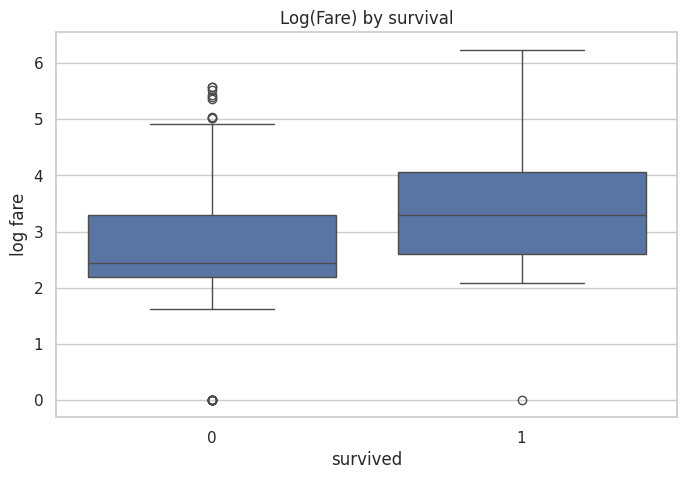

In [21]:
df['log_fare'] = np.log1p(df['fare'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='survived', y='log_fare')
plt.title("Log(Fare) by survival")
plt.xlabel("survived")
plt.ylabel("log fare")
plt.show()

Feature Engineering - Family size

In [22]:
df['family_size'] = df['sibsp'] + df['parch'] + 1


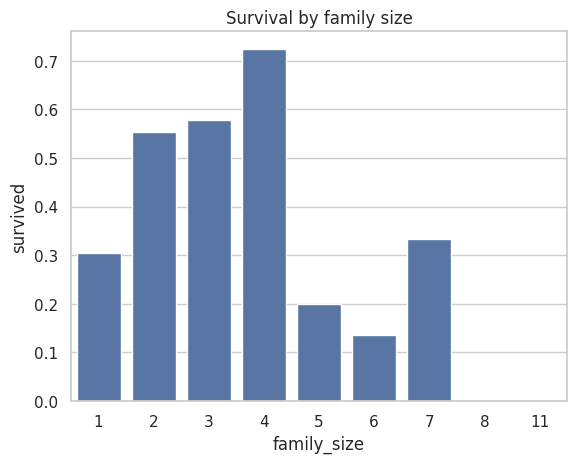

In [23]:
sns.barplot(data=df, x="family_size", y='survived', errorbar=None)
plt.title("Survival by family size")
plt.show()

child vs Adult

In [24]:
df['is_child']  = df['age'] < 16


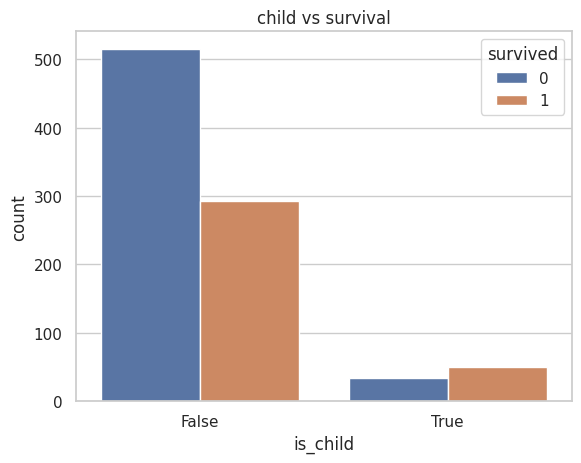

In [25]:
sns.countplot(data=df, x='is_child', hue='survived')
plt.title("child vs survival")
plt.show()

In [29]:
df['AgeGroup'] = pd.cut(df['age'], bins=[0,12,18,35,60,100], labels=['Child','Teen','Young','Adult','Senior'])

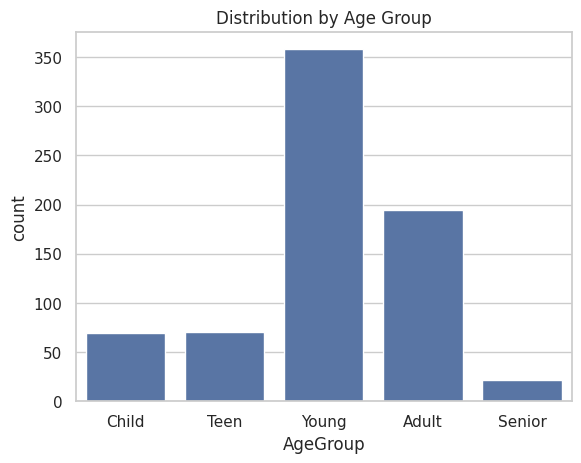

In [30]:
sns.countplot(data=df, x='AgeGroup')
plt.title("Distribution by Age Group")
plt.show()

Correlation Analysis

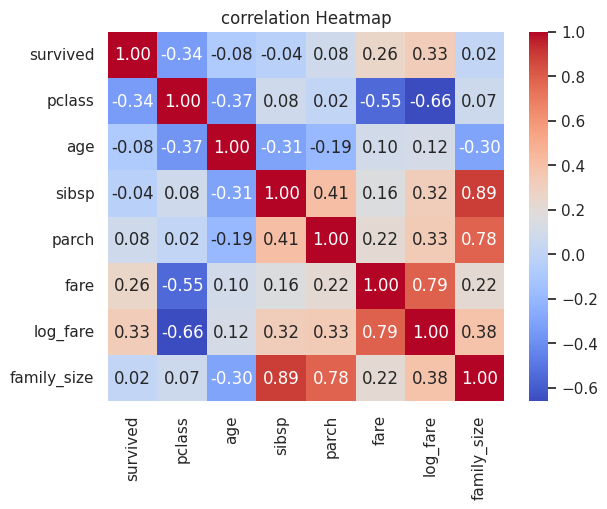

In [26]:
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt="0.2f", cmap="coolwarm")
plt.title("correlation Heatmap")
plt.show()

##Final Insights

1. Women survived more than men
2. First class had higher survival
3. Fare is linked with survival
4. Family size impacts survival
5. Missing values need handling before modeling

In [31]:
df.columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone', 'log_fare', 'family_size', 'is_child', 'AgeGroup'],
      dtype='object')